install libs

In [1]:
try:
	from sklearn.preprocessing import StandardScaler
	from sklearn.decomposition import TruncatedSVD
except ImportError:
	%pip install -q scikit-learn
	from sklearn.preprocessing import StandardScaler
	from sklearn.decomposition import TruncatedSVD

### Read data from parquet files


In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


# Define the directory containing the Parquet files
data_dir = os.path.join('data', 'iam_dataset')

# Read each Parquet file into a separate DataFrame
account_entitlements_df = pd.read_parquet(os.path.join(data_dir, 'account_entitlements.parquet'))
accounts_df = pd.read_parquet(os.path.join(data_dir, 'accounts.parquet'))
applications_df = pd.read_parquet(os.path.join(data_dir, 'applications.parquet'))
entitlement_group_assignments_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_assignments.parquet'))
entitlement_group_relations_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_relations.parquet'))
group_entitlements_df = pd.read_parquet(os.path.join(data_dir, 'group_entitlements.parquet'))
entitlement_groups_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_groups.parquet'))
entitlements_df = pd.read_parquet(os.path.join(data_dir, 'entitlements.parquet'))
identities_df = pd.read_parquet(os.path.join(data_dir, 'identities.parquet'))
resources_df = pd.read_parquet(os.path.join(data_dir, 'resources.parquet'))

# Print the shapes of the DataFrames
print(f"Shape of account_entitlements_df: {account_entitlements_df.shape}")
print(f"Shape of accounts_df: {accounts_df.shape}")
print(f"Shape of applications_df: {applications_df.shape}")
print(f"Shape of entitlement_group_assignments_df: {entitlement_group_assignments_df.shape}")
print(f"Shape of entitlement_group_relations_df: {entitlement_group_relations_df.shape}")
print(f"Shape of entitlement_groups_df: {entitlement_groups_df.shape}")
print(f"Shape of entitlements_df: {entitlements_df.shape}")
print(f"Shape of identities_df: {identities_df.shape}")
print(f"Shape of resources_df: {resources_df.shape}")

Shape of account_entitlements_df: (972420, 5)
Shape of accounts_df: (314631, 6)
Shape of applications_df: (1000, 4)
Shape of entitlement_group_assignments_df: (170010, 3)
Shape of entitlement_group_relations_df: (571, 2)
Shape of entitlement_groups_df: (711, 5)
Shape of entitlements_df: (22991, 5)
Shape of identities_df: (50000, 8)
Shape of resources_df: (2100, 5)


## EDA

### Distribution of accounts per user

In [3]:
# Group by 'identity_id' and count the number of accounts for each user
accounts_per_user = accounts_df.groupby('identity_id').size()

# Get the distribution of the number of accounts
account_distribution = accounts_per_user.value_counts()

print("Distribution of accounts per user:")
print(account_distribution)

Distribution of accounts per user:
6     9966
5     9911
7     9010
4     8772
9     7904
8     4192
10     245
Name: count, dtype: int64


### Distribution of entitlements per account

Distribution of entitlements per account:
1     240438
2      24193
20      9012
13      7010
5       5027
12      4041
17      4025
9       3968
14      3964
19      3031
10      1967
15      1962
18      1943
6       1055
8       1026
16       998
7        971
Name: count, dtype: int64


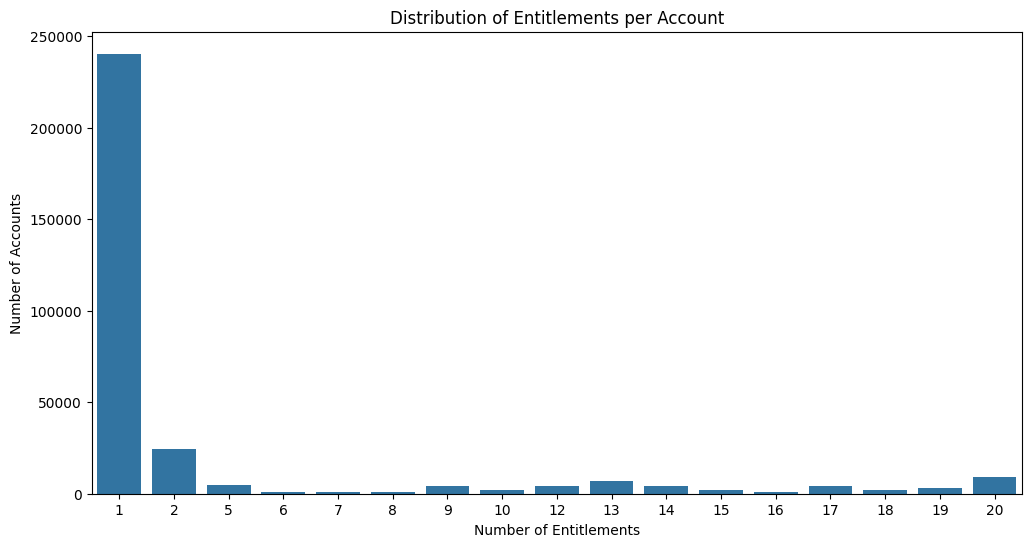

In [4]:


# --- Analysis for account_entitlements ---

# Group by 'account_id' and count the number of entitlements for each account
entitlements_per_account = account_entitlements_df.groupby('account_id').size()

# Get the distribution of the number of entitlements
entitlement_distribution = entitlements_per_account.value_counts()

print("Distribution of entitlements per account:")
print(entitlement_distribution)

# Create a bar plot of the entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_distribution.index, y=entitlement_distribution.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Entitlements per Account")
plt.show()




### Distribution of entitlement groups per identity:


Distribution of entitlement groups per identity:
3    31981
4    16028
5     1991
Name: count, dtype: int64


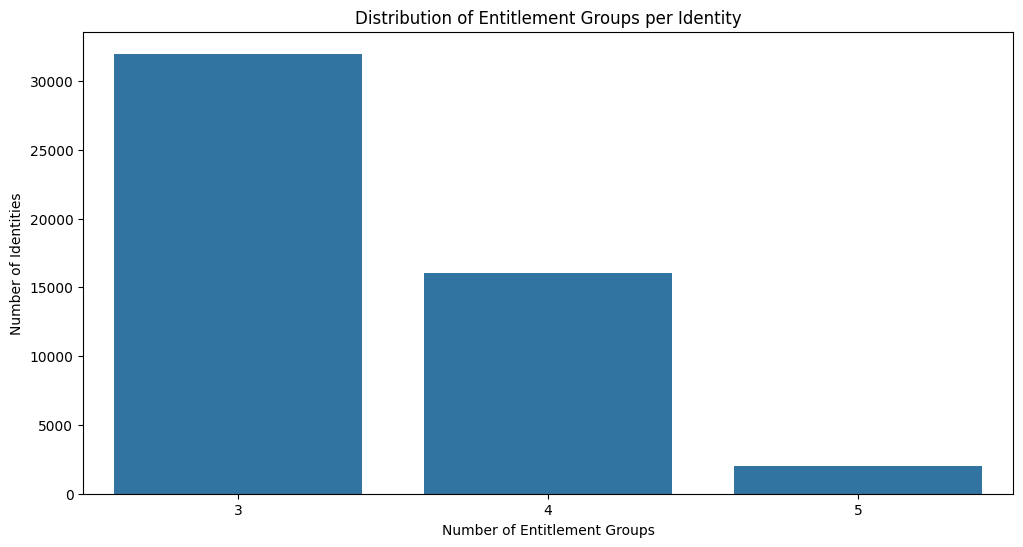

In [5]:
# --- Analysis for entitlement_group_assignments ---

# Group by 'identity_id' and count the number of entitlement groups for each identity
entitlement_groups_per_identity = entitlement_group_assignments_df.groupby('identity_id').size()

# Get the distribution of the number of entitlement groups
entitlement_group_distribution = entitlement_groups_per_identity.value_counts()

print("\nDistribution of entitlement groups per identity:")
print(entitlement_group_distribution)

# Create a bar plot of the entitlement group distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_group_distribution.index, y=entitlement_group_distribution.values)
plt.xlabel("Number of Entitlement Groups")
plt.ylabel("Number of Identities")
plt.title("Distribution of Entitlement Groups per Identity")
plt.show()

### Columns in each entity

In [6]:
print("applications_df columns:", applications_df.columns)
print("resources_df columns:", resources_df.columns)
print("entitlements_df columns:", entitlements_df.columns)
print("account_entitlements_df columns:", account_entitlements_df.columns)
print("accounts_df columns:", accounts_df.columns)

applications_df columns: Index(['app_id', 'app_name', 'business_criticality', 'app_owner_id'], dtype='str')
resources_df columns: Index(['resource_id', 'app_id', 'iga_source_name', 'connection_type',
       'resource_type'],
      dtype='str')
entitlements_df columns: Index(['entitlement_id', 'resource_id', 'entitlement_name', 'is_requestable',
       'owner_id'],
      dtype='str')
account_entitlements_df columns: Index(['identity_id', 'account_id', 'entitlement_id', 'grant_date',
       'assignment_type'],
      dtype='str')
accounts_df columns: Index(['identity_id', 'resource_id', 'account_id', 'account_name',
       'is_privileged', 'status'],
      dtype='str')


### Distribution of resources per application

Distribution of resources per application:
1     640
2     203
3      28
4      48
5      20
6       9
7       2
8       6
9       1
10      8
11      4
12      5
13      6
14      9
15     11
Name: count, dtype: int64


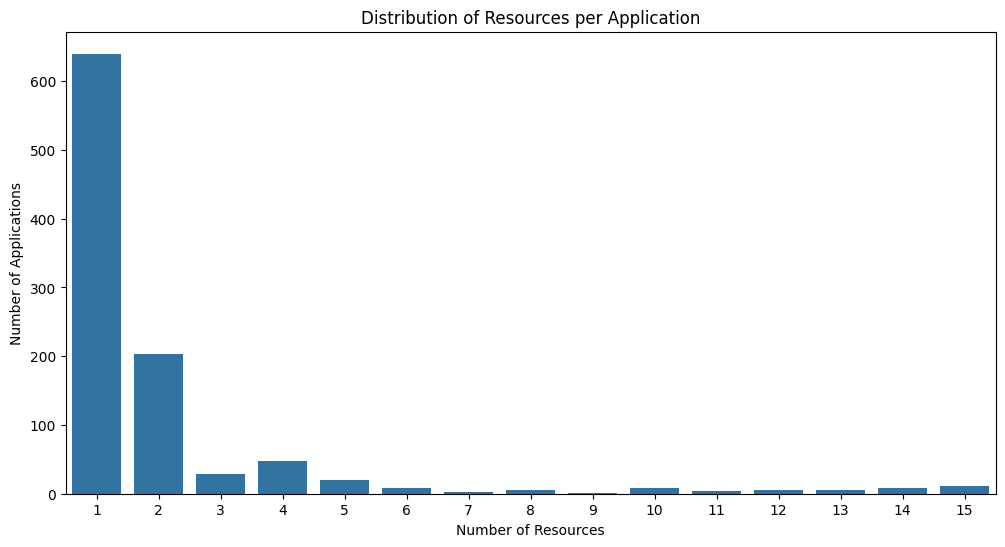

In [7]:
# --- Analysis for application to resource mapping ---

# Group by 'app_id' and count the number of resources for each application
resources_per_app = resources_df.groupby('app_id').size()

# Get the distribution of the number of resources
resource_distribution = resources_per_app.value_counts().sort_index()

print("Distribution of resources per application:")
print(resource_distribution)

# Create a bar plot of the resource distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_distribution.index, y=resource_distribution.values)
plt.xlabel("Number of Resources")
plt.ylabel("Number of Applications")
plt.title("Distribution of Resources per Application")
plt.show()

### Distribution of entitlements per resource

Distribution of entitlements per resource:
1      446
2      463
3      470
4       89
5       74
      ... 
454      1
459      1
460      1
469      1
474      1
Name: count, Length: 75, dtype: int64


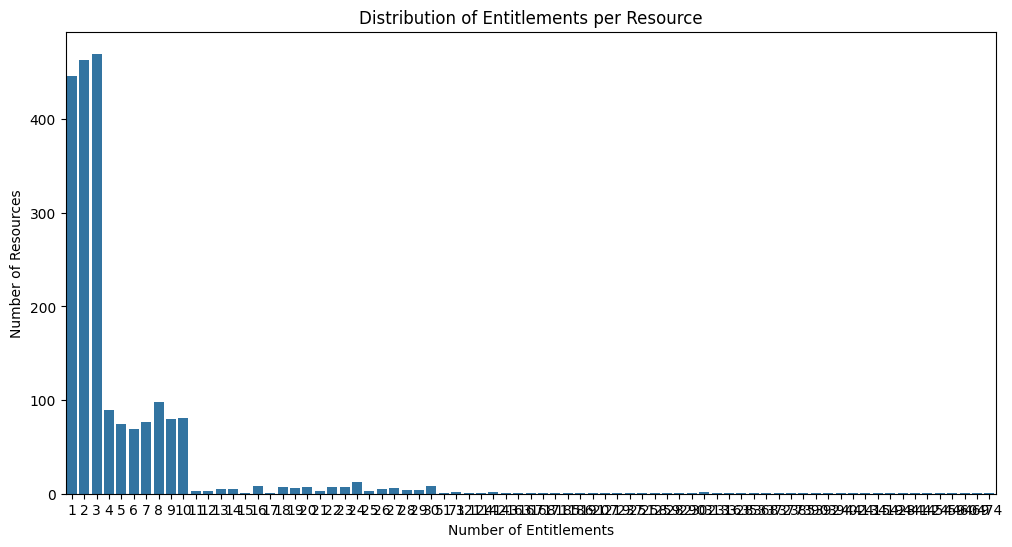

In [8]:
# --- Analysis for resource to entitlement mapping ---

# Group by 'resource_id' and count the number of entitlements for each resource
entitlements_per_resource = entitlements_df.groupby('resource_id').size()

# Get the distribution of the number of entitlements per resource
resource_entitlement_dist = entitlements_per_resource.value_counts().sort_index()

print("Distribution of entitlements per resource:")
print(resource_entitlement_dist)

# Create a bar plot of the resource to entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_entitlement_dist.index, y=resource_entitlement_dist.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Resources")
plt.title("Distribution of Entitlements per Resource")
plt.show()

### Distribution of accounts per entitlement:

Distribution of accounts per entitlement:
account_id
1       1077
2        128
3         22
4          3
939       12
        ... 
2018       1
2027       2
2032       1
2043       1
2947       1
Name: count, Length: 94, dtype: int64


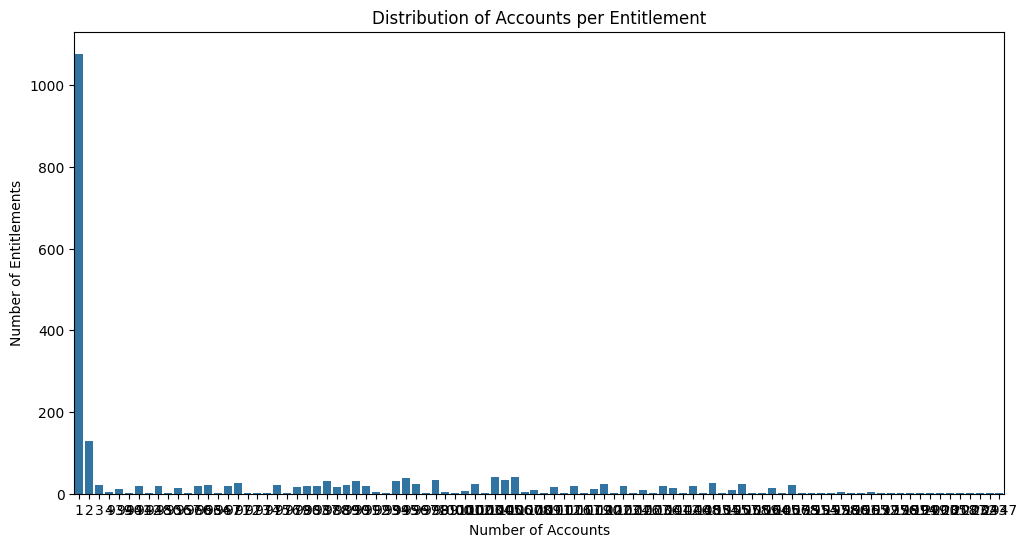

In [9]:
# --- Analysis for entitlement to account mapping ---

# Group by 'entitlement_id' and count the number of unique accounts for each entitlement
accounts_per_entitlement = account_entitlements_df.groupby('entitlement_id')['account_id'].nunique()

# Get the distribution of the number of accounts per entitlement
account_dist_per_entitlement = accounts_per_entitlement.value_counts().sort_index()

print("Distribution of accounts per entitlement:")
print(account_dist_per_entitlement)

# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=account_dist_per_entitlement.index, y=account_dist_per_entitlement.values)
plt.xlabel("Number of Accounts")
plt.ylabel("Number of Entitlements")
plt.title("Distribution of Accounts per Entitlement")
plt.show()

### Distribution of assignment counts per Entitlement Group

In [10]:
# User–entitlement mapping: merge account_entitlements with entitlements to get entitlement_name
user_entitlements_df = (
    account_entitlements_df[['identity_id', 'entitlement_id']]
    .merge(entitlements_df[['entitlement_id', 'entitlement_name']], on='entitlement_id', how='left')
    [['identity_id', 'entitlement_name']]
    .drop_duplicates()
)
print("user_entitlements_df shape:", user_entitlements_df.shape)
user_entitlements_df.head()

user_entitlements_df shape: (972419, 2)


,identity_id,entitlement_name
0,2e420c0e-7360-4c03-abe2-184c794f6254,Ent_TREE_9206
1,2e420c0e-7360-4c03-abe2-184c794f6254,Ent_AUTHOR_1911
2,2e420c0e-7360-4c03-abe2-184c794f6254,Ent_HOME_2386
3,2e420c0e-7360-4c03-abe2-184c794f6254,Ent_NIGHT_5978
4,2e420c0e-7360-4c03-abe2-184c794f6254,Ent_HEALTH_1542


Distribution of assignment counts per Entitlement Group:
31       1
34       1
35       1
38       1
39       3
        ..
5005     1
5018     1
5053     1
5084     1
50000    1
Name: count, Length: 140, dtype: int64


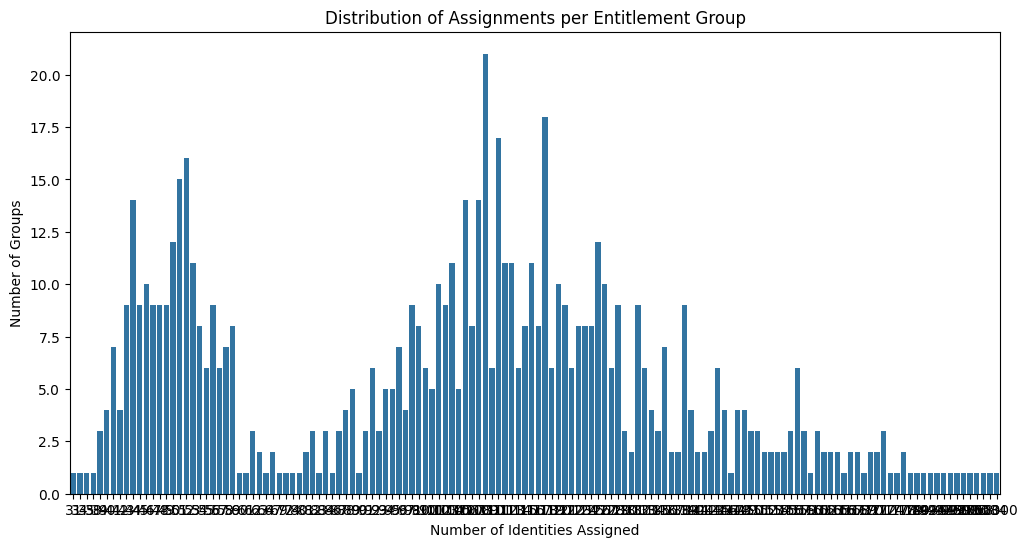

In [11]:
# --- Analysis for entitlement group assignment distribution ---

# Group by 'ent_group_id' and count the number of identities assigned to each group
group_size = entitlement_group_assignments_df.groupby('ent_group_id').size()

# Get the distribution of the number of assignments
group_dist = group_size.value_counts().sort_index()

print("Distribution of assignment counts per Entitlement Group:")
print(group_dist)

# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=group_dist.index.astype(int), y=group_dist.values)
plt.xlabel("Number of Identities Assigned")
plt.ylabel("Number of Groups")
plt.title("Distribution of Assignments per Entitlement Group")
plt.show()

## Feature Engineering Pipeline for IAM Clustering

The following cells build a mathematical feature matrix from `df_identities`, `df_entitlements`, and `df_user_entitlements` (identity_id, entitlement_name, risk_level) for unsupervised peer-group clustering.

In [12]:
# --- Step 1: Contextual Feature Engineering (HR Data) ---
# Isolate active users (assume column 'status' with value 'Active'; adjust if your schema differs)
active_identities_df = identities_df[identities_df['status'] == 'Active'].copy()

# One-Hot Encode department, job_title, location; set identity_id as index
hr_features_df = pd.get_dummies(
    active_identities_df[['identity_id', 'department', 'job_title', 'location']],
    columns=['department', 'job_title', 'location'],
    dtype=int
).set_index('identity_id')

print("Step 1 — HR features shape:", hr_features_df.shape)
hr_features_df.head()

Step 1 — HR features shape: (45151, 23577)


,department_Customer Support,department_Engineering,department_Finance,department_HR,department_IT,department_Legal,department_Marketing,department_Operations,department_Product,department_Sales,...,location_Zimmermanshire,location_Zimmermanstad,location_Zimmermantown,location_Zoeberg,location_Zoeburgh,location_Zoeside,location_Zunigamouth,location_Zunigaside,location_Zunigaton,location_Zunigatown
identity_id,,,,,,,,,,,,,,,,,,,,,
2e420c0e-7360-4c03-abe2-184c794f6254,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
819ac6a0-8504-4823-802f-92fd6074096e,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1cb6f71e-27d6-430d-88c9-425d7d66ceb6,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5e73a201-388c-4860-944d-6a2a2e54bb6c,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7621e1ff-5766-406e-91c5-1579e76f376c,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# --- Step 2: Behavioral Feature Engineering (User–Entitlement Sparse Matrix) ---
# Build binary User-Entitlement matrix: 1 if user holds entitlement, 0 otherwise
access_features_df = user_entitlements_df.assign(has_entitlement=1).pivot_table(
    index='identity_id',
    columns='entitlement_name',
    values='has_entitlement',
    aggfunc='max',
    fill_value=0
)

print("Step 2 — Access matrix shape:", access_features_df.shape)
access_features_df.iloc[:5, :5]

Step 2 — Access matrix shape: (50000, 2170)


entitlement_name,Ent_ABILITY_4636,Ent_ABILITY_5914,Ent_ABILITY_9126,Ent_ABLE_9194,Ent_ABOUT_6523
identity_id,,,,,
0001c3b1-9a75-41f7-812a-32389cf9c900,0,0,0,0,0
0001d551-5ffa-4556-990d-d9f9d7062fce,0,0,0,0,0
000218b1-bf85-4b93-9643-c1fe5ffb9033,0,0,0,0,0
00024dd4-04d4-4157-90c4-2840c75a40cc,0,0,0,0,0
0002b25b-e003-44ef-9ae6-199d7cb1b0cb,0,0,0,0,0


In [14]:
# --- Step 3: Aggregate Feature Creation ---
total_entitlements_count = account_entitlements_df.groupby('identity_id').size()

high_risk_entitlements_count = (
    account_entitlements_df
    .loc[account_entitlements_df['assignment_type'] == 'Adhoc_Anomaly']
    .groupby('identity_id')
    .size()
)

agg_features_df = pd.DataFrame({
    'total_entitlements_count': total_entitlements_count,
    'high_risk_entitlements_count': high_risk_entitlements_count
}).fillna(0).astype(int)

print("Step 3 — Aggregate features shape:", agg_features_df.shape)
agg_features_df.head()

Step 3 — Aggregate features shape: (50000, 2)


,total_entitlements_count,high_risk_entitlements_count
identity_id,,
0001c3b1-9a75-41f7-812a-32389cf9c900,25,0
0001d551-5ffa-4556-990d-d9f9d7062fce,17,0
000218b1-bf85-4b93-9643-c1fe5ffb9033,18,0
00024dd4-04d4-4157-90c4-2840c75a40cc,19,0
0002b25b-e003-44ef-9ae6-199d7cb1b0cb,27,0


In [15]:
# --- Step 4: Final Assembly & Scaling ---
try:
	from sklearn.preprocessing import StandardScaler
except ImportError:
	%pip install -q scikit-learn
	from sklearn.preprocessing import StandardScaler

# Concatenate HR, access, and aggregate features on identity_id index; fill NaNs with 0
master_feature_matrix_df = pd.concat(
    [hr_features_df, access_features_df, agg_features_df],
    axis=1,
    join='outer'
).fillna(0)

# Scale only aggregate numerical columns so they don't overpower binary columns
agg_cols = ['total_entitlements_count', 'high_risk_entitlements_count']
scaler = StandardScaler()
master_feature_matrix_df[agg_cols] = scaler.fit_transform(master_feature_matrix_df[agg_cols])

print("Step 4 — Master feature matrix shape:", master_feature_matrix_df.shape)
master_feature_matrix_df[agg_cols].describe()

Step 4 — Master feature matrix shape: (50000, 25749)


,total_entitlements_count,high_risk_entitlements_count
count,5.000000e+04,5.000000e+04
mean,1.273293e-16,-4.547474e-18
std,1.000010e+00,1.000010e+00
min,-2.173693e+00,-1.758631e-01
25%,-9.254484e-01,-1.758631e-01
50%,1.147553e-01,-1.758631e-01
75%,7.388774e-01,-1.758631e-01
max,1.987122e+00,5.686241e+00


In [16]:
# --- Step 5: Dimensionality Reduction (TruncatedSVD) ---
try:
	from sklearn.decomposition import TruncatedSVD
except ImportError:
	%pip install -q scikit-learn
	from sklearn.decomposition import TruncatedSVD

n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_reduced = svd.fit_transform(master_feature_matrix_df)

print("Step 5 — Reduced matrix shape:", X_reduced.shape)
print("\nExplained variance ratio (first 100 components):")
print(svd.explained_variance_ratio_)
print("\nCumulative explained variance:", svd.explained_variance_ratio_.sum())

Step 5 — Reduced matrix shape: (50000, 100)

Explained variance ratio (first 100 components):
[5.95156081e-02 4.21125203e-02 2.65206104e-02 2.58726375e-02
 2.51534449e-02 2.47741497e-02 2.40391894e-02 2.36905836e-02
 2.29213130e-02 1.97401259e-02 2.08490545e-02 2.18148353e-02
 2.16346638e-02 1.23350827e-02 1.94280488e-02 1.89590632e-02
 1.85998155e-02 1.83233241e-02 1.98751858e-02 1.95496414e-02
 1.91534531e-02 1.91044116e-02 1.85707682e-02 1.85001975e-02
 1.83098998e-02 1.79790574e-02 1.78067555e-02 1.76179688e-02
 1.73944978e-02 1.71276008e-02 1.68969621e-02 1.67701490e-02
 1.63577734e-02 1.60119456e-02 1.58510964e-02 1.57762620e-02
 1.57567273e-02 1.54910568e-02 1.51359750e-02 1.40025968e-02
 1.34717971e-02 1.30985790e-02 1.30178264e-02 1.28348300e-02
 1.24716286e-02 1.19829450e-02 1.15096557e-02 1.09386044e-02
 1.03567865e-02 1.02275081e-02 9.03435060e-03 3.72885645e-04
 3.71642652e-04 3.70670836e-04 3.57937905e-04 3.47503516e-04
 3.45874969e-04 3.41605682e-04 3.37933930e-04 3.2624